# Processing Proteomic data of ProCan-DepMapSanger
Here I perform pre-processing of the proteomics data from the ProCan-DepMapSanger project (https://pmc.ncbi.nlm.nih.gov/articles/PMC9387775/#da0010). The pridepy package was used to query data from the PRIDE database.

About the project:
* PRIDE identifier: PXD030304
* 949 human cancer cell lines, 40 cancer types
* Has 290 overlapping cell lines with the CCLE study
* 187 cell lines from lung
* DIA-MS, six replicates across 6 MS machines, preprocessed using DIA-NN version 1.8
* Also include data of drug response

In [1]:
import os
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import yaml

In [2]:
with open("../../config/config.local.yaml", "r") as f:
    config = yaml.safe_load(f)
basedir = config['code_dir']

data_input_dir = config["cell_line_data_dir"]
cell_line_data_filename = config["cell_line_data_filename"]
cell_line_metadata_filename = config["cell_line_metadata_filename"]

data_output_dir = os.path.join(config["output_data_dir"], "processed_proteomics_data")
if not os.path.exists(data_output_dir):
    os.makedirs(data_output_dir)

## Importing the data

In [3]:
proteome_df = pd.read_csv(os.path.join(data_input_dir, cell_line_data_filename), sep="\t", index_col=0, decimal=",")
metadata_df = pd.read_csv(os.path.join(data_input_dir, cell_line_metadata_filename), sep="\t", index_col=0, decimal=",")
proteome_df.head()

,P37108;SRP14_HUMAN,Q96JP5;ZFP91_HUMAN,Q9Y4H2;IRS2_HUMAN,P36578;RL4_HUMAN,Q6SPF0;SAMD1_HUMAN,O76031;CLPX_HUMAN,Q8WUQ7;CATIN_HUMAN,A6NIH7;U119B_HUMAN,Q9BTD8;RBM42_HUMAN,Q9P258;RCC2_HUMAN,...,P33151;CADH5_HUMAN,Q5EBL4;RIPL1_HUMAN,P49715;CEBPA_HUMAN,Q5TA45;INT11_HUMAN,O14924;RGS12_HUMAN,Q7Z3B1;NEGR1_HUMAN,O60669;MOT2_HUMAN,Q13571;LAPM5_HUMAN,Q96JM2;ZN462_HUMAN,P35558;PCKGC_HUMAN
Project_Identifier,,,,,,,,,,,,,,,,,,,,,
SIDM00018;K052,7.10955,3.41494,NaN,7.86661,3.89547,4.19666,NaN,NaN,3.19088,7.35806,...,NaN,NaN,3.90064,2.63998,NaN,NaN,NaN,NaN,NaN,NaN
SIDM00023;TE-12,6.82802,4.14346,2.23781,7.62878,3.19811,4.60902,NaN,2.47059,3.69535,5.70790,...,NaN,NaN,NaN,3.19608,NaN,NaN,NaN,NaN,NaN,NaN
SIDM00040;TMK-1,7.01426,4.19987,2.44055,8.12459,NaN,4.76881,NaN,NaN,NaN,5.52283,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SIDM00041;STS-0421,5.28591,3.35789,NaN,7.97268,NaN,4.52092,NaN,NaN,2.73088,4.29429,...,NaN,NaN,NaN,2.79023,NaN,NaN,NaN,NaN,NaN,NaN
SIDM00042;PL4,5.70786,NaN,NaN,6.22574,NaN,4.49579,NaN,NaN,2.87981,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
metadata_df.head()

,Project_Identifier,Cell_line,Source,Identifier,Gender,Tissue_type,Cancer_type,Cancer_subtype,Haem_lineage,BROAD_ID,...,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15
model_id,,,,,,,,,,,,,,,,,,,,,
SIDM00896,SIDM00896;BC-1,BC-1,ATCC,CVCL_1079,Male,Haematopoietic and Lymphoid,B-Cell Non-Hodgkin's Lymphoma,Primary effusion lymphoma,B lymphoid,ACH-002214,...,-0.460410592,0.769344541,1.655735696,2.109066796,-0.056366659,-0.550704882,0.22918636,0.48678876,0.299904549,-0.319624837
SIDM00312,SIDM00312;L-363,L-363,DSMZ,CVCL_1357,Female,Haematopoietic and Lymphoid,Plasma Cell Myeloma,NaN,B lymphoid,ACH-000183,...,0.586819719,1.267371741,3.302839254,1.927399012,1.67645876,-1.009455463,-0.329970134,0.530467659,0.585515536,-0.092114513
SIDM00277,SIDM00277;EoL-1-cell,EoL-1-cell,RIKEN,CVCL_0258,Male,Haematopoietic and Lymphoid,Acute Myeloid Leukemia,Chronic Eosinophilic Leukemia,Myeloid,ACH-000198,...,-1.023188467,-3.082193494,-1.778517568,0.218588171,-0.191836004,-1.5289751,0.444940467,-0.23824369,1.183521049,-0.245174026
SIDM01119,SIDM01119;NCI-H727,NCI-H727,ATCC,CVCL_1584,Female,Lung,Carcinoid Tumour,Lung Carcinoid Tumor,NaN,ACH-000775,...,1.15562679,1.266913309,-0.128102385,0.1088428,-0.895634273,-0.813593711,0.352701873,-1.68028983,0.4363571,-0.034756331
SIDM00657,SIDM00657;MV-4-11,MV-4-11,ATCC,CVCL_0064,Male,Haematopoietic and Lymphoid,Acute Myeloid Leukemia,Acute Monocytic leukemia,Myeloid,ACH-000045,...,-0.160455371,-2.825198424,-2.446800068,0.334810381,-2.487931171,-1.485627055,0.177513259,-0.218151504,0.501118696,-0.044598198


In [5]:
metadata_df = pd.DataFrame({"Project;cell line": proteome_df.index})
metadata_df["Project"] = metadata_df["Project;cell line"].apply(lambda x: x.split(";")[0])
metadata_df["cell line"] = metadata_df["Project;cell line"].apply(lambda x: x.split(";")[1])
metadata_df["Project"] = metadata_df["Project"].apply(lambda x: x.strip())
metadata_df["cell line"] = metadata_df["cell line"].apply(lambda x: x.strip())
metadata_df.head()

,Project;cell line,Project,cell line
0,SIDM00018;K052,SIDM00018,K052
1,SIDM00023;TE-12,SIDM00023,TE-12
2,SIDM00040;TMK-1,SIDM00040,TMK-1
3,SIDM00041;STS-0421,SIDM00041,STS-0421
4,SIDM00042;PL4,SIDM00042,PL4


In [6]:
proteome_df = proteome_df.transpose()
proteome_df.columns = [s.split(";")[1] for s in proteome_df.columns]
proteome_df["UniprotID"] = [s.split(";")[0] for s in proteome_df.index]
proteome_df["Gene"] = [s.split(";")[1] for s in proteome_df.index]
proteome_df["organism"] = [s.split("_")[1] for s in proteome_df["Gene"]]
proteome_df["Gene"] = [s.split("_")[0] for s in proteome_df["Gene"]]
proteome_df.set_index("Gene", inplace=True)
proteome_df.head()

,K052,TE-12,TMK-1,STS-0421,PL4,PCI-4B,PCI-30,HSC-39,H3255,EMC-BAC-2,...,BE-13,MC-IXC,Ramos-2G6-4C10,CGTH-W-1,H9,GR-ST,YMB-1-E,MM1S,UniprotID,organism
Gene,,,,,,,,,,,,,,,,,,,,,
SRP14,7.10955,6.82802,7.01426,5.28591,5.70786,6.73965,6.04591,6.20582,6.53547,6.80469,...,6.66480,7.02345,6.99319,6.31631,6.23087,7.00407,6.76532,6.91982,P37108,HUMAN
ZFP91,3.41494,4.14346,4.19987,3.35789,NaN,4.50199,3.69356,2.88118,NaN,2.78737,...,3.60415,3.12879,3.85570,4.86933,2.71686,NaN,3.75777,3.70284,Q96JP5,HUMAN
IRS2,NaN,2.23781,2.44055,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.07386,NaN,NaN,NaN,NaN,NaN,NaN,Q9Y4H2,HUMAN
RL4,7.86661,7.62878,8.12459,7.97268,6.22574,7.47364,7.07092,8.25336,6.47861,7.58653,...,6.99447,7.78652,7.32346,7.62433,7.23503,7.58150,7.24133,6.78319,P36578,HUMAN
SAMD1,3.89547,3.19811,NaN,NaN,NaN,NaN,3.49594,3.35439,NaN,2.14980,...,3.34052,3.24627,3.91503,3.92689,3.42065,NaN,3.05477,1.89549,Q6SPF0,HUMAN


In [7]:
proteome_df.index.name = "Gene"
proteome_df.reset_index(inplace=True)

In [8]:
# load functions for processing data and plotting
from proteome_2_anndata import proteome_2_anndata
from proteome_anndata_plot import *

In [10]:
adata = proteome_2_anndata(proteome_df = proteome_df, 
                           metadata_df = metadata_df,
                           match_sample_column="cell line",
                           match_protein_column="Gene",
                           protein_annotation_columns=["UniprotID", "organism"],
                           need_log2=False)
adata

INFO: No log2 intensity threshold specified. Threshold layers not computed.
INFO: AnnData object successfully created and returned.


AnnData object with n_obs × n_vars = 949 × 6692
    obs: 'index', 'Project;cell line', 'Project'
    var: 'UniprotID', 'organism'
    uns: 'intensity_threshold'
    obsm: 'number_detection_sample', 'missing_rate_sample'
    varm: 'missing_rate_gene', 'median_intensity', 'sum_intensity'

<Axes: xlabel='Proteins, ordered by sum of intensity', ylabel='Log2 intensity'>

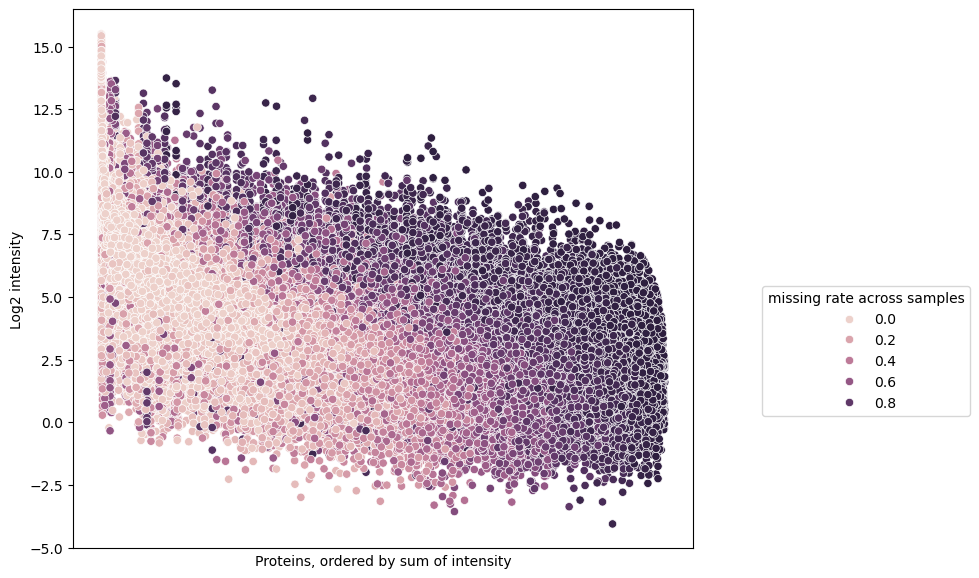

In [ ]:
plot_qc(adata)

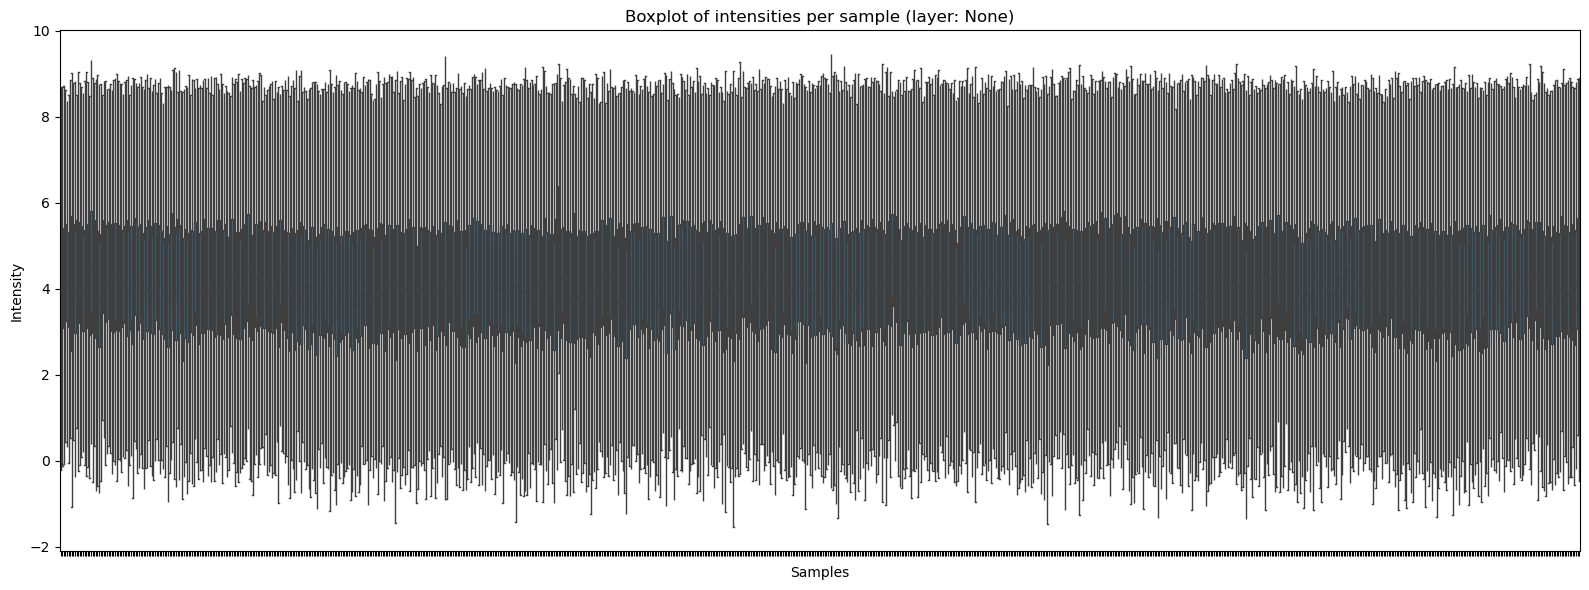

In [ ]:
boxplot_sample_intensities(adata)

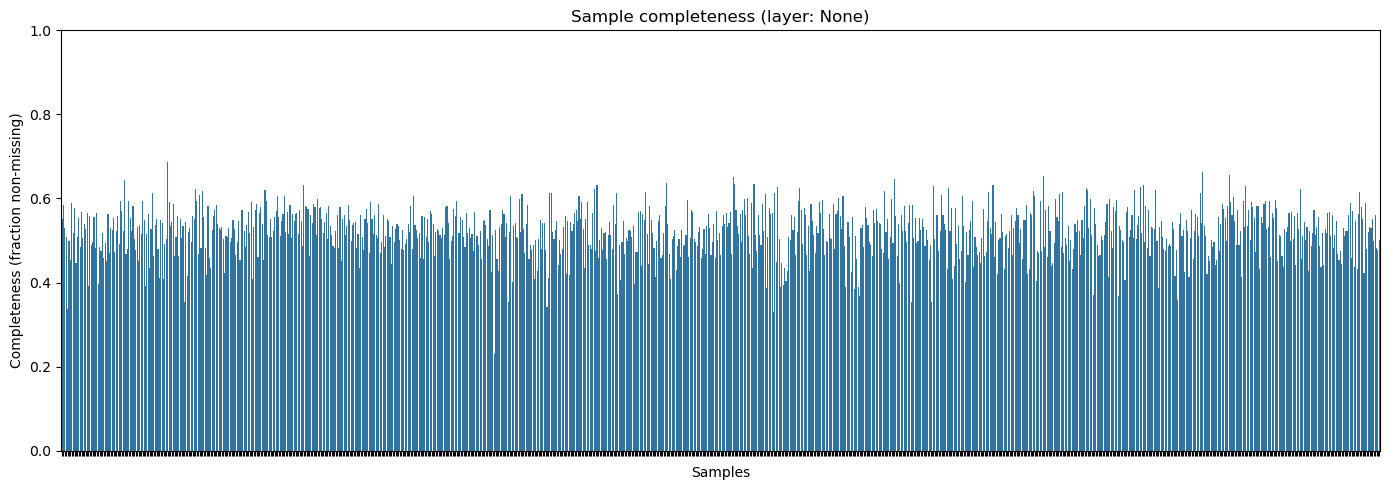

In [ ]:
plot_sample_completeness(adata)

In [11]:
adata.to_df()

Gene,1433B,1433E,1433F,1433G,1433S,1433T,1433Z,2A5D,2A5E,2A5G,...,ZO2,ZO3,ZPI,ZPLD1,ZPR1,ZRAB2,ZW10,ZWILC,ZWINT,ZYX
cell line,,,,,,,,,,,,,,,,,,,,,
K052,6.92955,6.53481,5.37869,7.81983,9.91057,6.69427,9.42748,2.84500,2.36483,NaN,...,2.11914,NaN,NaN,NaN,4.66696,5.82273,2.96899,2.24598,2.10489,6.22679
TE-12,7.49633,7.85489,5.71102,7.51368,10.50100,6.85081,10.07117,NaN,2.70403,2.66179,...,4.01638,3.04541,NaN,NaN,2.18918,4.00953,2.87247,NaN,NaN,3.12171
TMK-1,7.13270,6.95806,5.24447,7.86050,9.84154,6.00243,9.16914,3.36074,2.72862,NaN,...,4.43382,3.39217,NaN,NaN,5.35105,4.74386,2.49258,NaN,NaN,5.11104
STS-0421,6.35883,7.09459,5.98656,7.69563,10.82206,7.50230,9.80617,NaN,2.58891,NaN,...,5.02751,NaN,NaN,NaN,4.60495,4.94886,2.74363,NaN,NaN,7.00561
PL4,4.46387,4.84796,2.56077,3.85379,7.33660,3.38137,6.70774,NaN,NaN,NaN,...,3.40516,1.94142,NaN,NaN,NaN,3.21982,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CGTH-W-1,7.09100,7.87034,5.62704,7.17220,NaN,7.16391,9.03439,3.40424,2.95953,3.00567,...,3.85544,NaN,NaN,NaN,4.64494,4.67513,2.74816,NaN,2.71830,5.40782
H9,7.13223,7.95045,6.11358,8.36894,10.05486,7.34180,9.45323,3.48252,1.35762,NaN,...,NaN,NaN,NaN,NaN,4.19836,4.83970,1.81224,1.98577,1.70643,6.30450
GR-ST,6.82371,7.93507,5.66518,8.39093,NaN,7.25271,9.06892,2.68969,1.63399,3.70833,...,3.47891,NaN,NaN,NaN,5.17588,5.30529,2.92862,NaN,2.56982,2.65551


In [12]:
# save the anndata
adata.write(os.path.join(data_output_dir, "PanCancer_Goncalves2022_cancer_cell_lines.h5ad"))

... storing 'organism' as categorical
